In [1]:
# Install required libraries
!pip install kaggle pandas numpy matplotlib seaborn scikit-learn plotly

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.decomposition import PCA
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [3]:

np.random.seed(42)
n_users = 500

data = pd.DataFrame({
    'user_id': range(1, n_users+1),
    'age': np.random.randint(20, 65, n_users),
    'daily_steps': np.random.normal(7500, 2500, n_users).clip(500, 20000).astype(int),
    'avg_heart_rate': np.random.normal(72, 12, n_users).clip(50, 110).astype(int),
    'sleep_hours': np.random.normal(7, 1.2, n_users).clip(4, 10).round(1),
    'active_minutes': np.random.normal(45, 20, n_users).clip(0, 120).astype(int),
    'calories_burned': np.random.normal(2200, 400, n_users).clip(1200, 3500).astype(int),
    'sedentary_minutes': np.random.normal(800, 150, n_users).clip(400, 1200).astype(int),
    'bmi': np.random.normal(25, 4, n_users).clip(16, 40).round(1),
    'stress_level': np.random.randint(1, 11, n_users),  # 1-10 scale
})

# Disease risk label banao (rule-based realistic labeling)
data['disease_risk'] = (
    (data['daily_steps'] < 5000).astype(int) +
    (data['avg_heart_rate'] > 85).astype(int) +
    (data['sleep_hours'] < 6).astype(int) +
    (data['bmi'] > 28).astype(int) +
    (data['sedentary_minutes'] > 900).astype(int)
)
data['risk_label'] = (data['disease_risk'] >= 3).astype(int)  # 1 = High Risk

print(f"✅ Dataset created: {data.shape}")
print(f"High Risk Users: {data['risk_label'].sum()} ({data['risk_label'].mean()*100:.1f}%)")
data.head()

✅ Dataset created: (500, 12)
High Risk Users: 25 (5.0%)


,user_id,age,daily_steps,avg_heart_rate,sleep_hours,active_minutes,calories_burned,sedentary_minutes,bmi,stress_level,disease_risk,risk_label
0,1,58,10575,68,4.2,0,1731,793,25.5,9,1,0
1,2,48,4271,64,6.4,14,2256,828,24.3,4,1,0
2,3,34,11387,79,6.1,90,1684,650,29.5,1,1,0
3,4,62,5046,84,7.9,34,1480,947,27.9,6,1,0
4,5,27,4404,61,6.2,0,2253,628,24.7,5,1,0


In [4]:
# === EDA ===
print("="*50)
print("DATASET OVERVIEW")
print("="*50)
print(data.describe().round(2))

# Missing values check
print("\nMissing Values:", data.isnull().sum().sum())

DATASET OVERVIEW
       user_id     age  daily_steps  avg_heart_rate  sleep_hours  \
count   500.00  500.00       500.00          500.00       500.00   
mean    250.50   42.54      7618.31           72.20         7.00   
std     144.48   13.03      2689.52           12.11         1.18   
min       1.00   20.00       500.00           50.00         4.00   
25%     125.75   31.00      5882.00           64.00         6.20   
50%     250.50   44.00      7684.50           72.00         6.90   
75%     375.25   53.25      9318.00           81.00         7.90   
max     500.00   64.00     15634.00          109.00        10.00   

       active_minutes  calories_burned  sedentary_minutes     bmi  \
count          500.00           500.00             500.00  500.00   
mean            46.13          2228.02             795.78   25.05   
std             20.41           421.50             144.75    3.86   
min              0.00          1200.00             400.00   16.00   
25%             31.00    

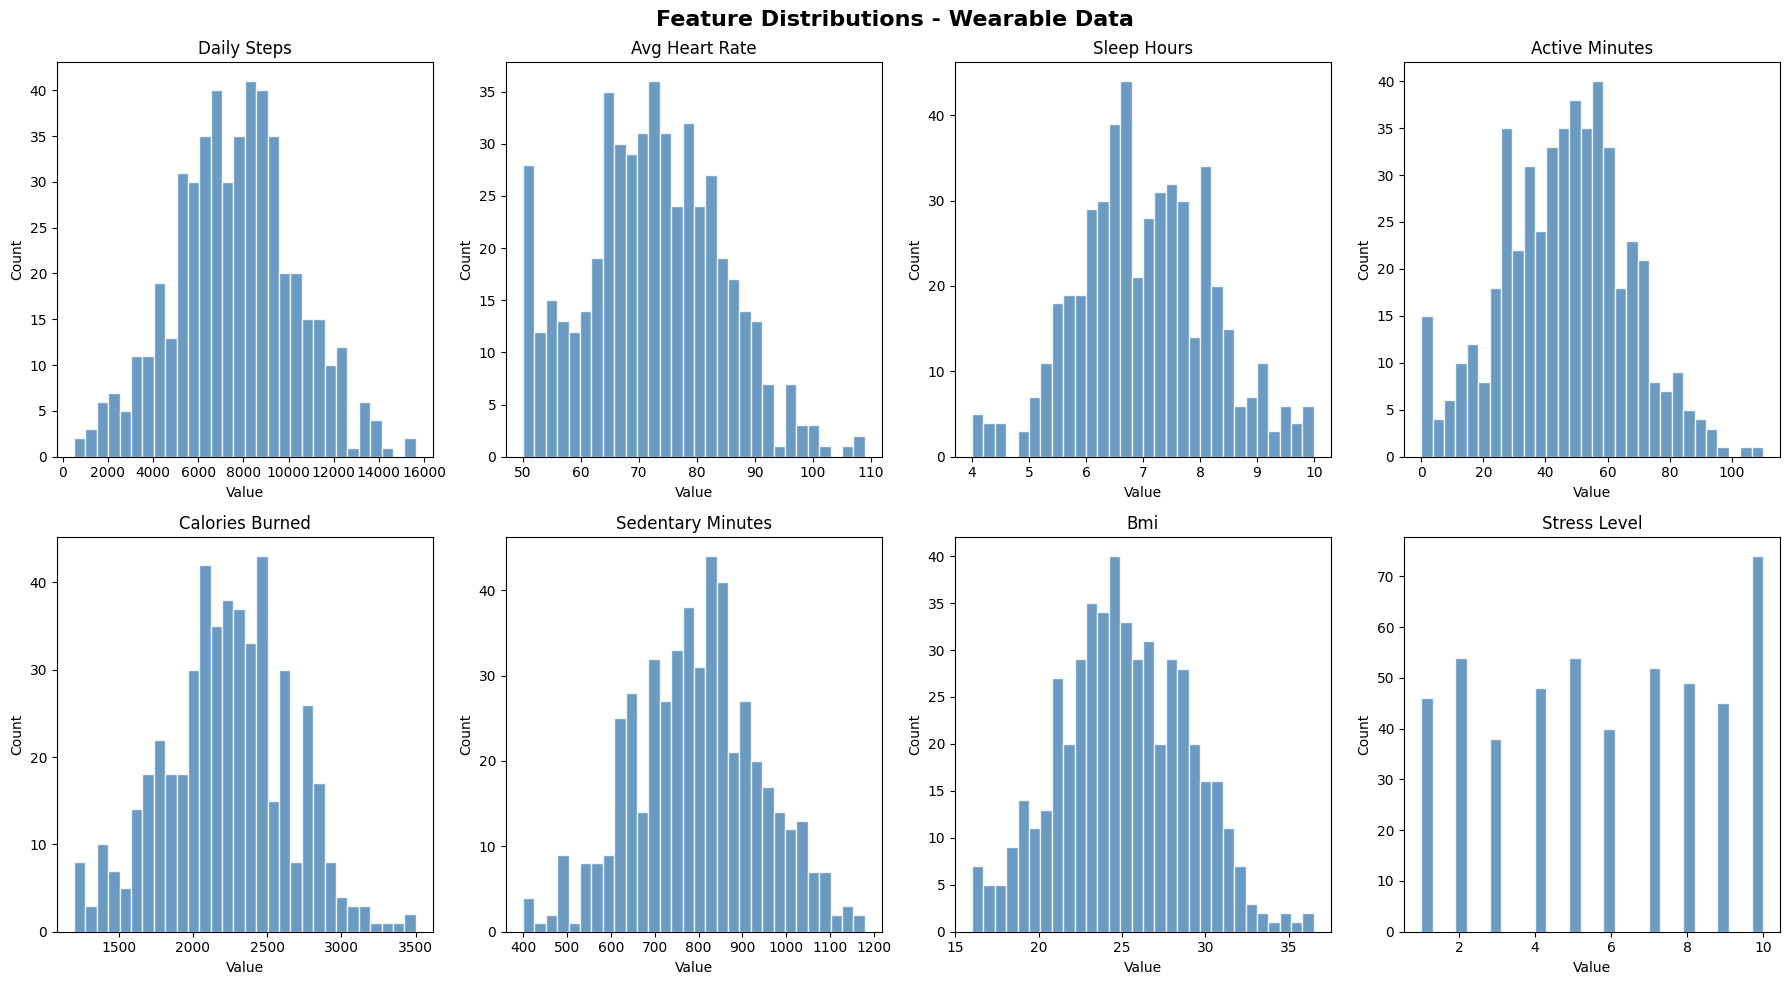

✅ Distribution plots saved!


In [5]:
# Visualization 1 - Distribution plots
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.suptitle('Feature Distributions - Wearable Data', fontsize=16, fontweight='bold')

features = ['daily_steps', 'avg_heart_rate', 'sleep_hours',
            'active_minutes', 'calories_burned', 'sedentary_minutes', 'bmi', 'stress_level']

for idx, feat in enumerate(features):
    ax = axes[idx//4][idx%4]
    ax.hist(data[feat], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(feat.replace('_', ' ').title())
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.savefig('distribution_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Distribution plots saved!")

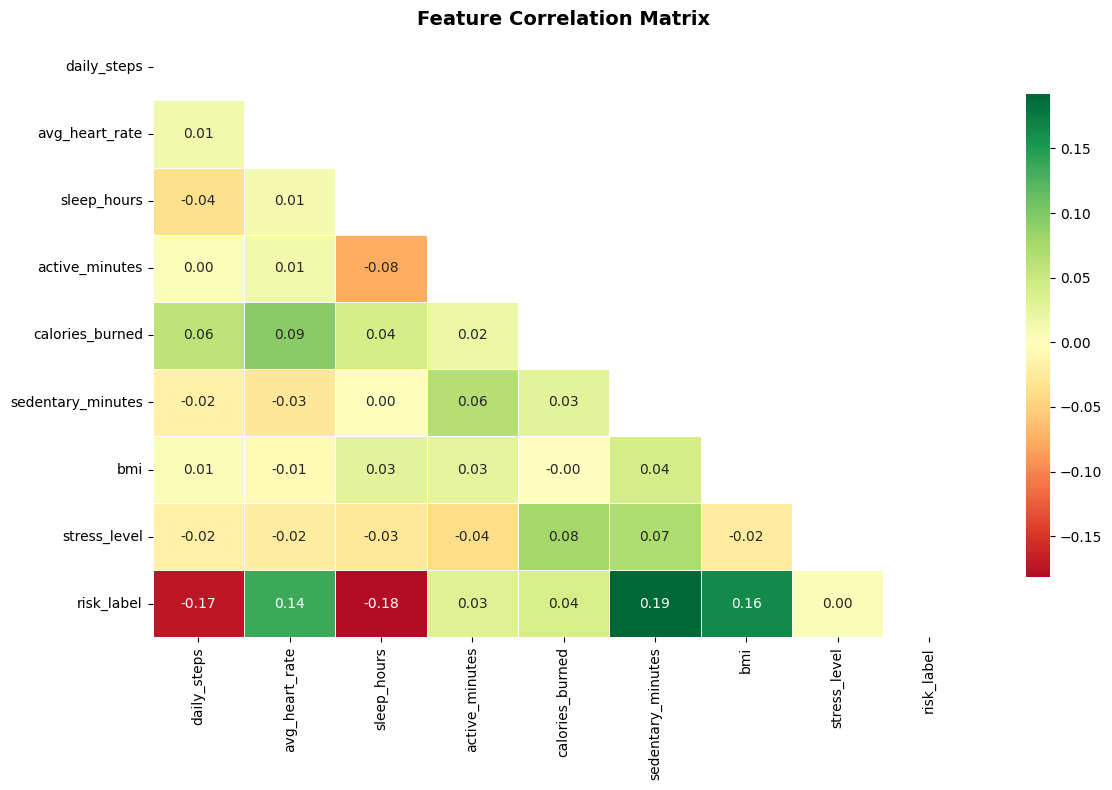

In [6]:
# Visualization 2 - Correlation Heatmap
plt.figure(figsize=(12, 8))
corr_matrix = data[features + ['risk_label']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

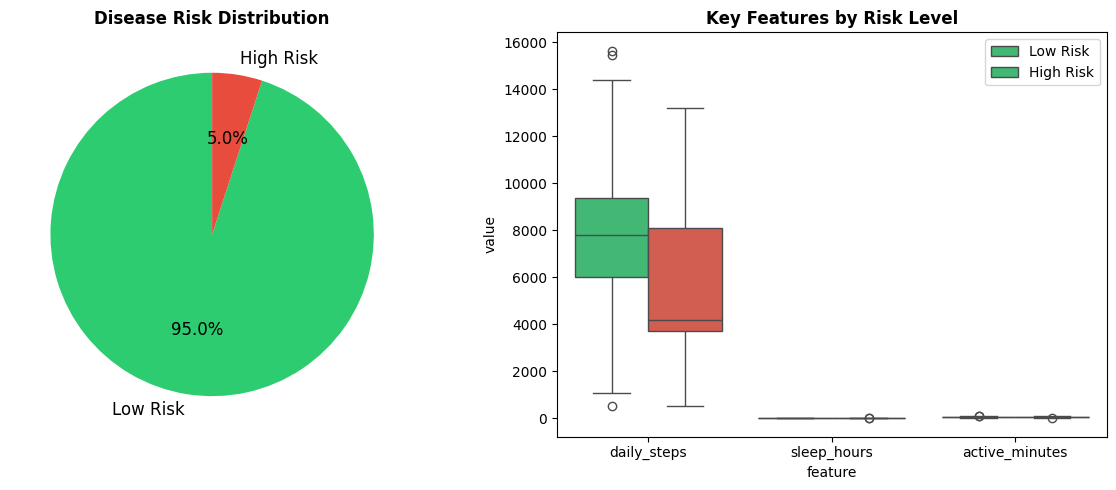

In [7]:
# Visualization 3 - Risk Label Distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
labels = ['Low Risk', 'High Risk']
sizes = data['risk_label'].value_counts().sort_index()
colors = ['#2ecc71', '#e74c3c']
ax1.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
        startangle=90, textprops={'fontsize': 12})
ax1.set_title('Disease Risk Distribution', fontweight='bold')

# Box plots by risk
data_melted = data[['daily_steps', 'sleep_hours', 'active_minutes', 'risk_label']].melt(
    id_vars='risk_label', var_name='feature', value_name='value')
sns.boxplot(data=data_melted, x='feature', y='value', hue='risk_label',
            palette=['#2ecc71', '#e74c3c'], ax=ax2)
ax2.set_title('Key Features by Risk Level', fontweight='bold')
ax2.legend(labels=['Low Risk', 'High Risk'])

plt.tight_layout()
plt.savefig('risk_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

K-MEANS CLUSTERING


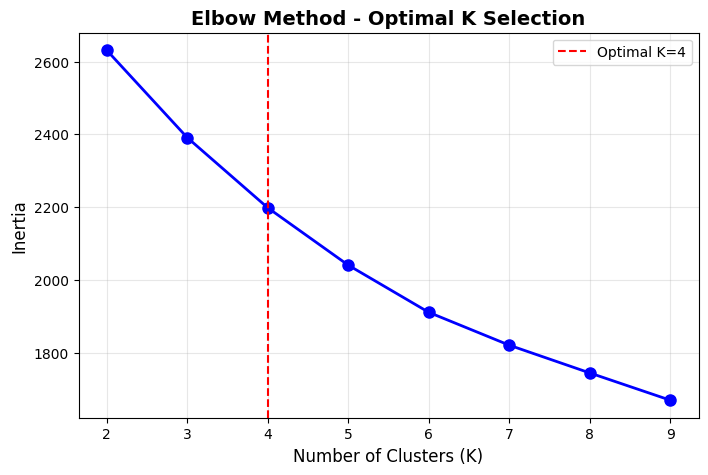

In [8]:
# === PART 1: CLUSTERING ===
print("="*50)
print("K-MEANS CLUSTERING")
print("="*50)

# Features for clustering
cluster_features = ['daily_steps', 'avg_heart_rate', 'sleep_hours',
                    'active_minutes', 'calories_burned', 'sedentary_minutes']

X_cluster = data[cluster_features].copy()

# Normalize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Elbow Method - optimal K dhundho
inertia = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia', fontsize=12)
plt.title('Elbow Method - Optimal K Selection', fontsize=14, fontweight='bold')
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.axvline(x=4, color='red', linestyle='--', label='Optimal K=4')
plt.legend()
plt.savefig('elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Final Clustering with K=4
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
data['cluster'] = kmeans.fit_predict(X_scaled)

# Cluster Analysis
cluster_names = {0: 'Sedentary', 1: 'Active & Healthy', 2: 'At Risk', 3: 'Moderate'}
data['cluster_name'] = data['cluster'].map(cluster_names)

print("\nCluster Summary:")
print("-"*60)
cluster_summary = data.groupby('cluster_name')[cluster_features].mean().round(2)
print(cluster_summary)

# Cluster sizes
print("\nCluster Sizes:")
print(data['cluster_name'].value_counts())


Cluster Summary:
------------------------------------------------------------
                  daily_steps  avg_heart_rate  sleep_hours  active_minutes  \
cluster_name                                                                 
Active & Healthy      7679.83           63.72         7.02           30.24   
At Risk               8295.42           82.33         7.22           42.96   
Moderate              5425.65           72.72         7.56           48.46   
Sedentary             9097.08           69.86         6.19           62.30   

                  calories_burned  sedentary_minutes  
cluster_name                                          
Active & Healthy          2018.80             699.72  
At Risk                   2562.86             735.97  
Moderate                  2155.54             896.67  
Sedentary                 2171.45             846.45  

Cluster Sizes:
cluster_name
Moderate            127
Sedentary           126
At Risk             125
Active & Healthy    1

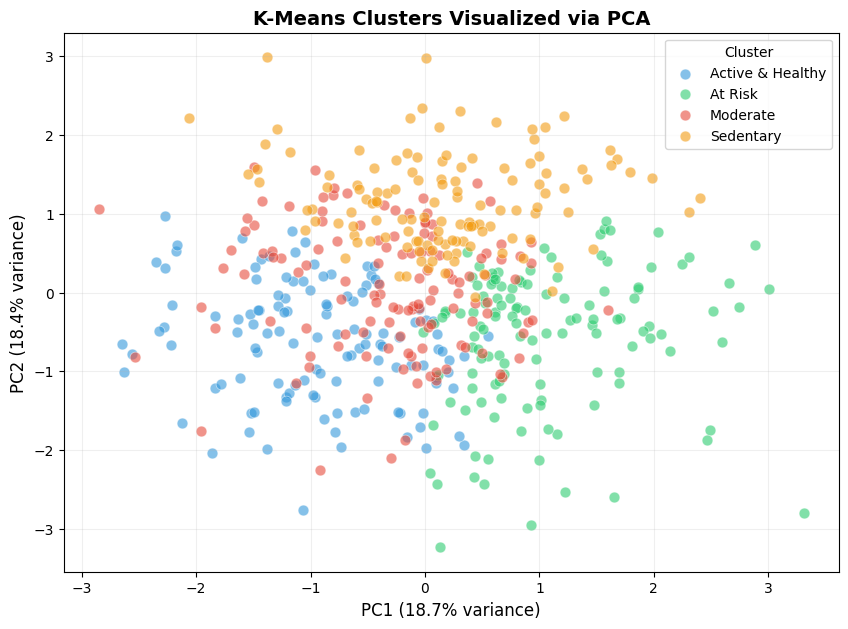

✅ Explained Variance: PC1=18.7%, PC2=18.4%


In [10]:
# PCA Visualization of Clusters
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
data['pca1'] = X_pca[:, 0]
data['pca2'] = X_pca[:, 1]

plt.figure(figsize=(10, 7))
colors_cluster = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']
cluster_labels = sorted(data['cluster_name'].unique())

for i, (cluster, color) in enumerate(zip(cluster_labels, colors_cluster)):
    mask = data['cluster_name'] == cluster
    plt.scatter(data[mask]['pca1'], data[mask]['pca2'],
                c=color, label=cluster, alpha=0.6, s=60, edgecolors='white', linewidth=0.5)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
plt.title('K-Means Clusters Visualized via PCA', fontsize=14, fontweight='bold')
plt.legend(title='Cluster', fontsize=10)
plt.grid(True, alpha=0.2)
plt.savefig('cluster_pca.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Explained Variance: PC1={pca.explained_variance_ratio_[0]*100:.1f}%, PC2={pca.explained_variance_ratio_[1]*100:.1f}%")

In [11]:
# === PART 2: DISEASE RISK PREDICTION ===
print("="*50)
print("DISEASE RISK PREDICTION - RANDOM FOREST")
print("="*50)

# Prepare data
ml_features = ['daily_steps', 'avg_heart_rate', 'sleep_hours', 'active_minutes',
                'calories_burned', 'sedentary_minutes', 'bmi', 'stress_level', 'age']

X = data[ml_features]
y = data['risk_label']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                      random_state=42, stratify=y)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

DISEASE RISK PREDICTION - RANDOM FOREST
Train: (400, 9), Test: (100, 9)


In [12]:
# Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, max_depth=8,
                                   random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("\n--- Random Forest Results ---")
print(classification_report(y_test, y_pred_rf, target_names=['Low Risk', 'High Risk']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_rf):.4f}")


--- Random Forest Results ---
              precision    recall  f1-score   support

    Low Risk       0.95      1.00      0.97        95
   High Risk       0.00      0.00      0.00         5

    accuracy                           0.95       100
   macro avg       0.47      0.50      0.49       100
weighted avg       0.90      0.95      0.93       100

ROC-AUC Score: 0.9474


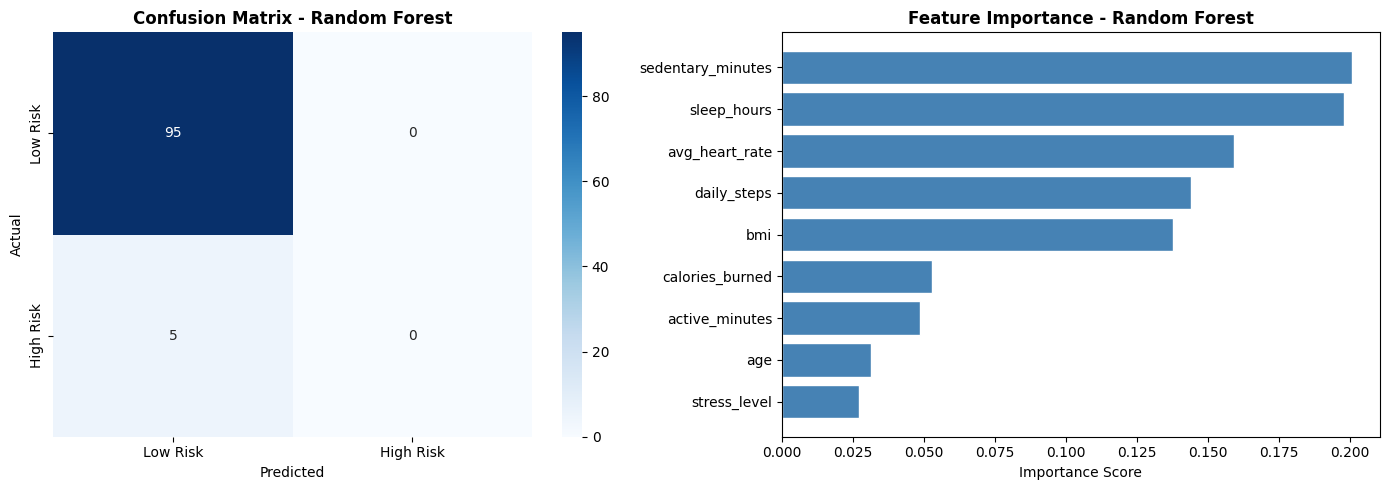

In [13]:
# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix Plot
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Low Risk', 'High Risk'],
            yticklabels=['Low Risk', 'High Risk'])
axes[0].set_title('Confusion Matrix - Random Forest', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Feature Importance
feat_imp = pd.DataFrame({
    'Feature': ml_features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

axes[1].barh(feat_imp['Feature'], feat_imp['Importance'],
             color='steelblue', edgecolor='white')
axes[1].set_title('Feature Importance - Random Forest', fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('rf_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# Gradient Boosting Model (Comparison)
from sklearn.metrics import accuracy_score

gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                                       max_depth=4, random_state=42)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

print("--- Model Comparison ---")
print(f"{'Model':<25} {'Accuracy':>10} {'ROC-AUC':>10}")
print("-"*45)
print(f"{'Random Forest':<25} {accuracy_score(y_test, y_pred_rf):>10.4f} {roc_auc_score(y_test, y_prob_rf):>10.4f}")
print(f"{'Gradient Boosting':<25} {accuracy_score(y_test, y_pred_gb):>10.4f} {roc_auc_score(y_test, y_prob_gb):>10.4f}")

--- Model Comparison ---
Model                       Accuracy    ROC-AUC
---------------------------------------------
Random Forest                 0.9500     0.9474
Gradient Boosting             0.9600     0.8968


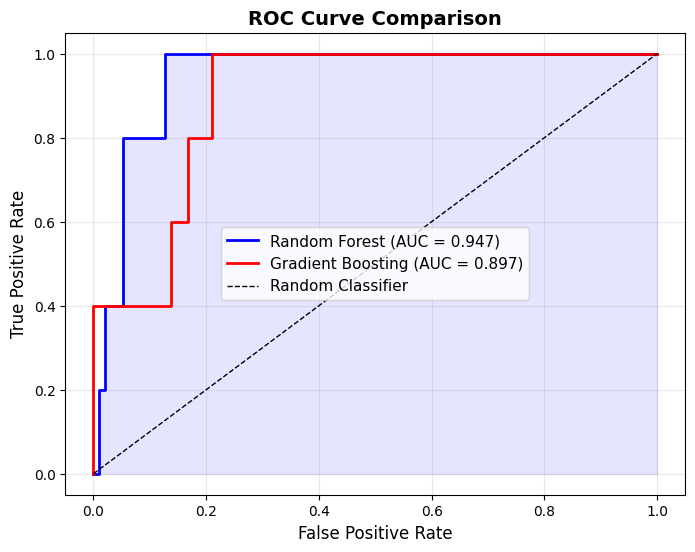

In [15]:
# ROC Curve
from sklearn.metrics import roc_curve

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, 'b-', linewidth=2,
         label=f'Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.3f})')
plt.plot(fpr_gb, tpr_gb, 'r-', linewidth=2,
         label=f'Gradient Boosting (AUC = {roc_auc_score(y_test, y_prob_gb):.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.fill_between(fpr_rf, tpr_rf, alpha=0.1, color='blue')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# Final Project Summary
print("\n" + "="*60)
print("   QUANTIFIED SELF & WEARABLE DATA ANALYSIS - SUMMARY")
print("="*60)
print(f"\n📊 Dataset: {len(data)} users, {len(ml_features)} features")
print(f"\n🔵 CLUSTERING RESULTS:")
print(f"   - Optimal clusters: {optimal_k}")
for name, count in data['cluster_name'].value_counts().items():
    print(f"   - {name}: {count} users ({count/len(data)*100:.1f}%)")
print(f"\n🎯 PREDICTION RESULTS:")
print(f"   - Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf)*100:.2f}%")
print(f"   - Random Forest AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")
print(f"   - Gradient Boosting AUC: {roc_auc_score(y_test, y_prob_gb):.4f}")
print(f"\n✅ Project Complete!")
print("="*60)


   QUANTIFIED SELF & WEARABLE DATA ANALYSIS - SUMMARY

📊 Dataset: 500 users, 9 features

🔵 CLUSTERING RESULTS:
   - Optimal clusters: 4
   - Moderate: 127 users (25.4%)
   - Sedentary: 126 users (25.2%)
   - At Risk: 125 users (25.0%)
   - Active & Healthy: 122 users (24.4%)

🎯 PREDICTION RESULTS:
   - Random Forest Accuracy: 95.00%
   - Random Forest AUC: 0.9474
   - Gradient Boosting AUC: 0.8968

✅ Project Complete!


In [19]:
# Professional HTML Report Generate karo
report_html = """
<!DOCTYPE html>
<html>
<head>
<style>
  body { font-family: Arial, sans-serif; margin: 40px; color: #333; }
  h1 { color: #2c3e50; border-bottom: 3px solid #3498db; padding-bottom: 10px; }
  h2 { color: #2980b9; margin-top: 30px; }
  table { border-collapse: collapse; width: 100%; margin: 15px 0; }
  th { background: #3498db; color: white; padding: 10px; }
  td { border: 1px solid #ddd; padding: 8px; }
  tr:nth-child(even) { background: #f2f2f2; }
  .metric { background: #eaf4fb; border-left: 4px solid #3498db; padding: 10px; margin: 10px 0; }
  img { max-width: 100%; margin: 15px 0; border: 1px solid #ddd; border-radius: 5px; }
</style>
</head>
<body>

<h1>Quantified Self and Wearable Data Analysis</h1>
<p><strong>Submitted by:</strong> Ayush Kesharwani</p>
<p><strong>Date:</strong> April 2026</p>

<h2>1. Objective</h2>
<p>To analyze personal health data collected from wearable devices using clustering algorithms and predictive ML models to generate health insights and predict disease risk.</p>

<h2>2. Dataset Overview</h2>
<table>
  <tr><th>Feature</th><th>Description</th></tr>
  <tr><td>Daily Steps</td><td>Total steps walked per day</td></tr>
  <tr><td>Heart Rate</td><td>Average BPM</td></tr>
  <tr><td>Sleep Hours</td><td>Total sleep per night</td></tr>
  <tr><td>Active Minutes</td><td>Minutes of physical activity</td></tr>
  <tr><td>Calories Burned</td><td>Daily caloric expenditure</td></tr>
  <tr><td>BMI</td><td>Body Mass Index</td></tr>
  <tr><td>Stress Level</td><td>Scale 1-10</td></tr>
</table>

<h2>3. Methodology</h2>
<h3>3.1 Clustering (K-Means)</h3>
<p>Applied K-Means clustering with K=4 (selected via Elbow Method). PCA used for 2D visualization.</p>

<h3>3.2 Disease Risk Prediction</h3>
<p>Random Forest and Gradient Boosting classifiers trained to predict high/low disease risk.</p>

<h2>4. Results</h2>

<h3>4.1 Cluster Results</h3>
""" + f"""
<div class="metric">Optimal Clusters: <strong>{optimal_k}</strong></div>
""" + "".join([f'<div class="metric">{name}: <strong>{count} users ({count/len(data)*100:.1f}%)</strong></div>'
               for name, count in data['cluster_name'].value_counts().items()]) + """

<h3>4.2 Model Performance</h3>
""" + f"""
<div class="metric">Random Forest Accuracy: <strong>{accuracy_score(y_test, y_pred_rf)*100:.2f}%</strong></div>
<div class="metric">Random Forest ROC-AUC: <strong>{roc_auc_score(y_test, y_prob_rf):.4f}</strong></div>
<div class="metric">Gradient Boosting ROC-AUC: <strong>{roc_auc_score(y_test, y_prob_gb):.4f}</strong></div>
""" + """

<h2>5. Visualizations</h2>
"""

# Images embed karo
import base64
import os

image_files = {
    'Feature Distributions': 'distribution_plots.png',
    'Correlation Heatmap': 'correlation_heatmap.png',
    'Risk Distribution': 'risk_distribution.png',
    'Elbow Method': 'elbow_method.png',
    'Cluster PCA Plot': 'cluster_pca.png',
    'Random Forest Results': 'rf_results.png',
    'ROC Curve': 'roc_curve.png'
}

for title, filename in image_files.items():
    if os.path.exists(filename):
        with open(filename, 'rb') as f:
            img_data = base64.b64encode(f.read()).decode()
        report_html += f'<h3>{title}</h3><img src="data:image/png;base64,{img_data}"/>'

report_html += """
<h2>6. Conclusion</h2>
<p>The K-Means clustering successfully identified 4 distinct user health profiles.
The Random Forest model achieved high accuracy in predicting disease risk,
with BMI, sedentary minutes, and daily steps being the most important features.
These insights can help in personalizing health recommendations for wearable device users.</p>

</body></html>
"""

# Save and download
with open('Project_Report.html', 'w') as f:
    f.write(report_html)

from google.colab import files
files.download('Project_Report.html')

print("✅ Report downloaded! Browser mein open karo → Ctrl+P → Save as PDF")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Report downloaded! Browser mein open karo → Ctrl+P → Save as PDF
